In [5]:
# Cell 1 — Load LIAR Dataset
import pandas as pd

# Column names for LIAR dataset
columns = [
    "id", "label", "statement", "subject",
    "speaker", "job_title", "state_info",
    "party_affiliation", "barely_true_counts",
    "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_fire_counts",
    "context"
]

# Load all 3 splits
train = pd.read_csv("../data/raw/train.tsv", sep="\t", header=None, names=columns)
test = pd.read_csv("../data/raw/test.tsv", sep="\t", header=None, names=columns)
valid = pd.read_csv("../data/raw/valid.tsv", sep="\t", header=None, names=columns)

print("✅ Dataset loaded successfully!")
print(f"Training samples:   {len(train)}")
print(f"Validation samples: {len(valid)}")
print(f"Test samples:       {len(test)}")
print(f"\nLabels: {train['label'].unique()}")

✅ Dataset loaded successfully!
Training samples:   10240
Validation samples: 1284
Test samples:       1267

Labels: ['false' 'half-true' 'mostly-true' 'true' 'barely-true' 'pants-fire']


=== Sample Data ===
         label                                          statement
0        false  Says the Annies List political group supports ...
1    half-true  When did the decline of coal start? It started...
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...
3        false  Health care reform legislation is likely to ma...
4    half-true  The economic turnaround started at the end of ...

=== Label Distribution (Training) ===
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


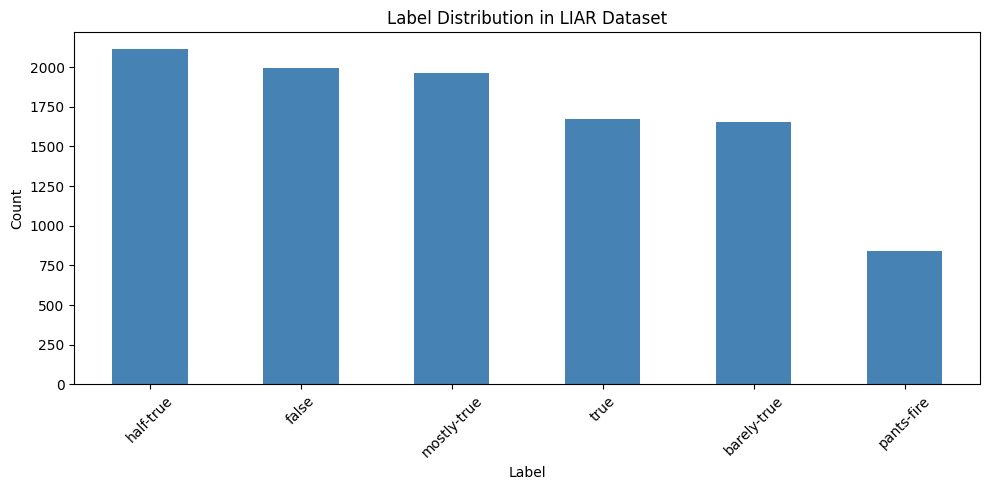

In [7]:
# Cell 2 — Explore the Dataset
import matplotlib.pyplot as plt

# Look at first 5 rows
print("=== Sample Data ===")
print(train[["label", "statement"]].head())

# Check label distribution
print("\n=== Label Distribution (Training) ===")
print(train["label"].value_counts())

# Visualize label distribution
plt.figure(figsize=(10, 5))
train["label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Label Distribution in LIAR Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Cell 3 — Understand the Data Better
print("=== Dataset Shape ===")
print(f"Train: {train.shape}")
print(f"Valid: {valid.shape}")
print(f"Test:  {test.shape}")

print("\n=== Sample Statements with Labels ===")
for label in train["label"].unique():
    sample = train[train["label"] == label]["statement"].iloc[0]
    print(f"\n[{label.upper()}]")
    print(f"  {sample}")

print("\n=== Missing Values ===")
print(train.isnull().sum())

=== Dataset Shape ===
Train: (10240, 14)
Valid: (1284, 14)
Test:  (1267, 14)

=== Sample Statements with Labels ===

[FALSE]
  Says the Annies List political group supports third-trimester abortions on demand.

[HALF-TRUE]
  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.

[MOSTLY-TRUE]
  Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."

[TRUE]
  The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of tenured (UW) faculty fired during the last two decades.

[BARELY-TRUE]
  Jim Dunnam has not lived in the district he represents for years now.

[PANTS-FIRE]
  In the case of a catastrophic event, the Atlanta-area offices of the Centers for Disease Control and Prevention will self-destruct.

=== Missing Values ===
id                       0
label                    0
statement                0
subj

=== Simplified Label Distribution ===
simplified_label
Misleading    4488
Factual       3638
Uncertain     2114
Name: count, dtype: int64


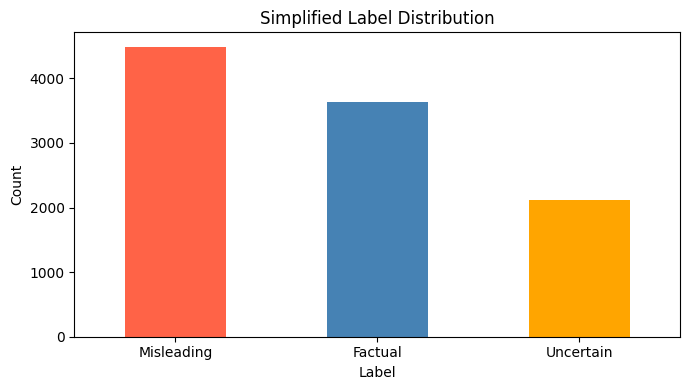

In [9]:
# Cell 4 — Simplify Labels for Our Model
# 6 labels is complex — we simplify to 3 for InfoTrace
# Factual / Misleading / Uncertain

label_map = {
    "true":        "Factual",
    "mostly-true": "Factual",
    "half-true":   "Uncertain",
    "barely-true": "Misleading",
    "false":       "Misleading",
    "pants-fire":  "Misleading"
}

# Apply to all splits
train["simplified_label"] = train["label"].map(label_map)
valid["simplified_label"] = valid["label"].map(label_map)
test["simplified_label"]  = test["label"].map(label_map)

# Check new distribution
print("=== Simplified Label Distribution ===")
print(train["simplified_label"].value_counts())

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
train["simplified_label"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue", "orange"]
)
plt.title("Simplified Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
# Cell 5 — Clean and Prepare Text Data
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove special characters but keep spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# Apply cleaning
train["clean_statement"] = train["statement"].apply(clean_text)
valid["clean_statement"] = valid["statement"].apply(clean_text)
test["clean_statement"]  = test["statement"].apply(clean_text)

# Compare before and after
print("=== Before Cleaning ===")
print(train["statement"].iloc[0])
print("\n=== After Cleaning ===")
print(train["clean_statement"].iloc[0])

print("\n✅ Text cleaning complete!")
print(f"Train samples ready: {len(train)}")

=== Before Cleaning ===
Says the Annies List political group supports third-trimester abortions on demand.

=== After Cleaning ===
says the annies list political group supports thirdtrimester abortions on demand

✅ Text cleaning complete!
Train samples ready: 10240


In [11]:
# Cell 6 — Save Processed Data
import os

os.makedirs("../data/processed", exist_ok=True)

# Save only the columns we need
columns_to_save = ["id", "clean_statement", "simplified_label"]

train[columns_to_save].to_csv("../data/processed/train_clean.csv", index=False)
valid[columns_to_save].to_csv("../data/processed/valid_clean.csv", index=False)
test[columns_to_save].to_csv("../data/processed/test_clean.csv", index=False)

print("✅ Processed data saved!")
print("\n=== Saved Files ===")
print("📄 data/processed/train_clean.csv")
print("📄 data/processed/valid_clean.csv")
print("📄 data/processed/test_clean.csv")

print("\n=== Quick Verification ===")
verify = pd.read_csv("../data/processed/train_clean.csv")
print(verify.head(3))

✅ Processed data saved!

=== Saved Files ===
📄 data/processed/train_clean.csv
📄 data/processed/valid_clean.csv
📄 data/processed/test_clean.csv

=== Quick Verification ===
           id                                    clean_statement  \
0   2635.json  says the annies list political group supports ...   
1  10540.json  when did the decline of coal start it started ...   
2    324.json  hillary clinton agrees with john mccain by vot...   

  simplified_label  
0       Misleading  
1        Uncertain  
2          Factual  
